# Aprendizado por Reforço

---

**Professor:** Prof. Gabriel Lima  
**Aula:** 03  
**Exercício:** 3A  

---

### Objetivo :  
Implementar os algoritmos:

- Iterative Policy Evaluation
- Policy Iteration
- Value Iteration

## Bibliotecas Utilizadas

Para a implementação dos algoritmos utilizaremos as seguintes bibliotecas:

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import io

## Definição do Ambiente

Considere o seguinte ambiente a ser implementado:


![image.png](attachment:image.png)

- 𝒮 = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}  
- 𝒮⁺ = {0, 15}  
- 𝒜 = {↑, →, ↓, ←}  

- ℛ(s, a) = −1 para qualquer ação tomada em um estado **não terminal**  
- ℛ(s, a) = 0 para qualquer ação tomada em um estado **terminal** (sombreado)  

- 𝒫 é **determinístico**, ou seja, 𝒫ₛₛ′ᵃ são matrizes binárias com ∑ₛ′ 𝒫ₛₛ′ᵃ = 1, ∀ s,a e o estado sucessor é o indicado pela ação.

- O agente permanece no mesmo estado caso tome ações que o levem para fora do grid, ou esteja em um estado terminal.

- 𝛾 = 1

- 𝜋(↑│s) = 𝜋(→│s) = 𝜋(↓│s) = 𝜋(←│s) = 0.25, ∀ s ∈ 𝒮  
  (Política estocástica uniforme)

In [ ]:
class GridWorld:

    def __init__(self):
        self.size = 4
        self.grid = np.array([[0,1,1,1],
                              [1,1,1,1],
                              [1,1,1,1],
                              [1,1,1,0]])
        self.Frames   = []
        self.positions= []
        self.action_space  = ['UP','DOWN','LEFT','RIGHT']
        self.state_space   = [(y,x) for y in range(self.size) for x in range(self.size)]

    def step(self,action,state):

        y,x = state
        terminal = False

        if action == 'UP' and y > 0 and not terminal:
            y -=1

        elif action == 'DOWN' and y < self.size-1 and not terminal:
            y +=1

        elif action == 'LEFT' and x > 0 and not terminal:
            x -=1

        elif action == 'RIGHT' and x < self.size-1 and not terminal:
            x +=1

        next_state = (y,x)

        if self.grid[state[0]][state[1]] == 0:
                terminal = True
                next_state = state

        self.positions.append(next_state)

        return self.state_space.index(next_state), 0 if (state == (3,3) or
                                                         state == (0,0)) \
                                                         else -1,terminal

    def show(self):

        for position in self.positions:

            fig, ax = plt.subplots()
            cax = ax.imshow(self.grid, cmap='Blues', interpolation='nearest')
            ax.grid(True, which='both', color='black', linestyle='--', linewidth=0.5)
            ax.scatter(position[1], position[0], s=128, color='r')


            ax.set_xticks(np.arange(-0.5, 4, 1))
            ax.set_yticks(np.arange(-0.5, 4, 1))
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_aspect('equal', adjustable='box')

            buf = io.BytesIO()
            fig.savefig(buf, orientation='landscape')
            buf.seek(0)
            img = Image.open(buf)

            self.Frames.append(img)

        return self.Frames

## Instanciando o Ambiente

É então instanciado o ambiente.

In [ ]:
env = GridWorld()

Para testar a classe, um step é realizado.

In [ ]:
env.step('RIGHT',(3,2))

(15, -1, False)

## Definindo a Política

Para cada estado o agente terá a probabilidade uniforme de executar uma ação:

In [ ]:
random_policy = 0.25*np.ones((16,4))

## Iterative Policy Evaluation

**Objetivo:** Estimar o valor dos estados sob uma política fixa 𝜋.

***Equação de Bellman para política fixa:***


Para todo estado s ∈ 𝒮:

**V(s) = ∑ₐ π(a│s) ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]**

### Algoritmo:

**Entrada:**
- Política 𝜋
- Função de transição 𝒫
- Função de recompensa ℛ
- Fator de desconto γ
- Limite de tolerância θ

**Inicialização:**
- V(s) ← valor arbitrário (ex: 0), ∀ s ∈ 𝒮

**Repetir:**
1. Δ ← 0  
2. Para cada estado s ∈ 𝒮:  
   a. v ← V(s)  
   b. V(s) ← ∑ₐ π(a│s) ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]  
   c. Δ ← max(Δ, |v − V(s)|)  
3. Até que Δ < θ

**Saída:**  
- Função de valor V(s) para todos os estados sob a política 𝜋

In [ ]:
def IterativePolicyEvaluation(env,policy:np.array,theta:float,gamma=float):
    n = len(env.state_space)
    m = len(env.action_space)

    V_k = np.zeros(n)
    k = 0

    while True:
        delta = 0

        V_k1 = np.zeros(n)
        for states in range(n):
            state = env.state_space[states]
            v = 0
            for action in range(m):
                next_state,reward,_ = env.step(env.action_space[action],state)
                v += policy[states][action]*(reward+ gamma*V_k[next_state])

            V_k1[states] = v
            delta = max([delta, abs(V_k1[states] - V_k[states])])

        V_k = np.copy(V_k1)
        k+=1

        if delta < theta:
            break

    return V_k1,k


In [ ]:
V,k  = IterativePolicyEvaluation(env,random_policy,0.0000000001,1)

In [ ]:
print(f'Convergencia realizada em {k} iteracoes')

Convergencia realizada em 426 iteracoes


### Visualização

In [ ]:
def plot_value_function(env,V):
    value_function_matrix = np.zeros(np.shape(env.grid))

    for states in range(len(V)):
        state = env.state_space[states]
        value_function_matrix[state[0]][state[1]] = V[states]

    fig = plt.figure()
    ax = fig.gca()
    C = ax.imshow(value_function_matrix, interpolation='nearest', cmap='RdYlGn')
    fig.colorbar(C, ax=ax)
    ax.set_title('GridWorld: Value Function')

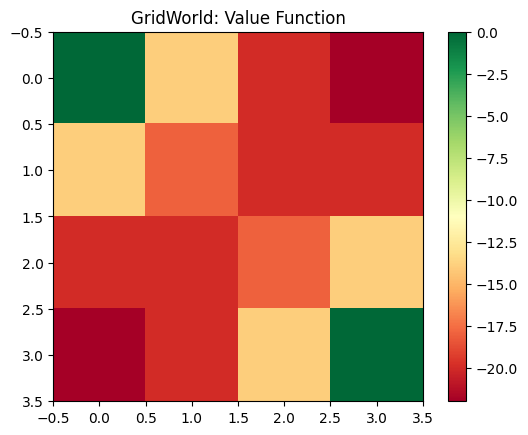

In [ ]:
plot_value_function(env,V)

## Policy Iteration

**Objetivo:** Encontrar a política ótima 𝜋* por meio de iterações de avaliação e melhoria de política.

***Etapas principais:***

1. **Avaliação de Política (Policy Evaluation)**  
   Utiliza a Equação de Bellman para uma política fixa:
   
   **V(s) = ∑ₐ π(a│s) ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]**

2. **Melhoria de Política (Policy Improvement)**  
   Atualiza a política escolhendo a melhor ação com base em V(s):

   **π′(s) = argmaxₐ ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]**

### Algoritmo:

**Entrada:**
- Função de transição 𝒫
- Função de recompensa ℛ
- Conjunto de ações 𝒜
- Fator de desconto γ
- Tolerância θ para a avaliação de política

**Inicialização:**
- Inicializar π(s) arbitrariamente para todos s ∈ 𝒮  
- Inicializar V(s) arbitrariamente (ex: 0) para todos s ∈ 𝒮

**Repetir:**
1. **[Policy Evaluation]**  
   - Usar Iterative Policy Evaluation para calcular V(s) sob π até convergência (Δ < θ)

2. **[Policy Improvement]**  
   - policy_stable ← True  
   - Para cada estado s ∈ 𝒮:  
     a. a_old ← π(s)  
     b. π(s) ← argmaxₐ ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]  
     c. Se a_old ≠ π(s): policy_stable ← False

3. Até que policy_stable seja **True**

**Saída:**  
- Política ótima 𝜋*  
- Função de valor V* associada


In [ ]:
def policy_improvement(env,V,gamma):
  n = len(env.state_space)
  m = len(env.action_space)
  greedy_policy = np.zeros((n,m))

  for states in range(n):
    state = env.state_space[states]
    q_list = []
    for action in range(m):
      next_state,reward,done = env.step(env.action_space[action],state)

      if done:
        q_list.append(reward)
      else:
        q_list.append(reward + gamma*V[next_state])

    max_q = np.argmax(q_list)
    greedy_policy[states,max_q] = 1

  return greedy_policy

In [ ]:
print(V)

[  0. -14. -20. -22. -14. -18. -20. -20. -20. -20. -18. -14. -22. -20.
 -14.   0.]


In [ ]:
policy_improvement(env,V,1)

array([[1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.]])

In [ ]:
def PolicyIteration(env,gamma,theta):
    n = len(env.state_space)
    m = len(env.action_space)

    old_policy = 0.25*np.ones((n,m))

    stable = False

    while not stable:
        V,k = IterativePolicyEvaluation(env,old_policy,theta,gamma)
        policy = policy_improvement(env,V,gamma)

        if (policy == old_policy).all():
            stable = True

        old_policy = np.copy(policy)

    return V,policy

In [ ]:
V_otimo,pi_otimo = PolicyIteration(env,1,0.0000000001)

In [ ]:
V_otimo

array([ 0., -1., -2., -3., -1., -2., -3., -2., -2., -3., -2., -1., -3.,
       -2., -1.,  0.])

### Visualização

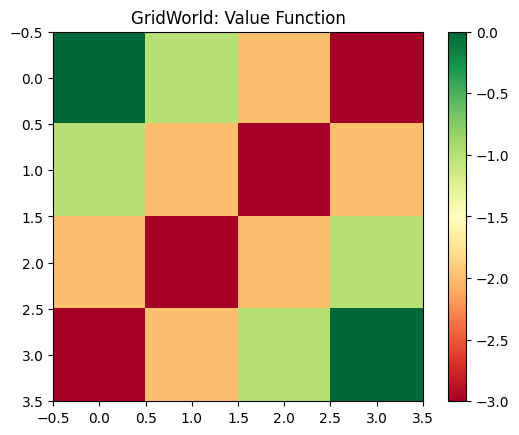

In [ ]:
plot_value_function(env,V_otimo)

## Value Iteration

**Objetivo:** Encontrar a função de valor ótima V* e derivar a política ótima 𝜋* a partir dela.


***Equação de Bellman ótima:***

Para todo estado s ∈ 𝒮:

**V(s) = maxₐ ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]**

### Algoritmo:

**Entrada:**
- Função de transição 𝒫
- Função de recompensa ℛ
- Conjunto de ações 𝒜
- Fator de desconto γ
- Tolerância θ

**Inicialização:**
- V(s) ← valor arbitrário (ex: 0), ∀ s ∈ 𝒮

**Repetir:**
1. Δ ← 0  
2. Para cada estado s ∈ 𝒮:  
   a. v ← V(s)  
   b. V(s) ← maxₐ ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]  
   c. Δ ← max(Δ, |v − V(s)|)  
3. Até que Δ < θ

**Derivar política ótima:**
- Para cada estado s ∈ 𝒮:  
  π*(s) = argmaxₐ ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]

**Saída:**  
- Função de valor ótima V*  
- Política ótima 𝜋*

In [ ]:
def ValueIteration(env,gamma,theta):
  n = len(env.state_space)
  m = len(env.action_space)

  V_k = np.zeros(n)

  k = 0

  while True:
    delta = 0
    V_k1 = np.zeros(n)

    for states in range(n):
      state = env.state_space[states]
      q_list = []
      for action in range(m):
        next_state,reward,done = env.step(env.action_space[action],state)
        q = reward + gamma*V_k[next_state]
        q_list.append(q)

      V_k1[states] = np.max(q_list)

      delta = max([delta, abs(V_k1[states] - V_k[states])])

    V_k = np.copy(V_k1)
    k+=1

    if delta < theta:
      break

  return V_k1

In [ ]:
V_otimo_value_iteration = ValueIteration(env,1,0.0000000001)

### Visualização

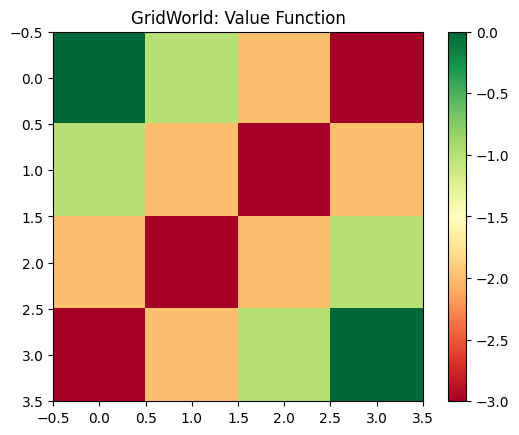

In [ ]:
plot_value_function(env,V_otimo_value_iteration)